Gerando gráfico em Português com Rótulos...


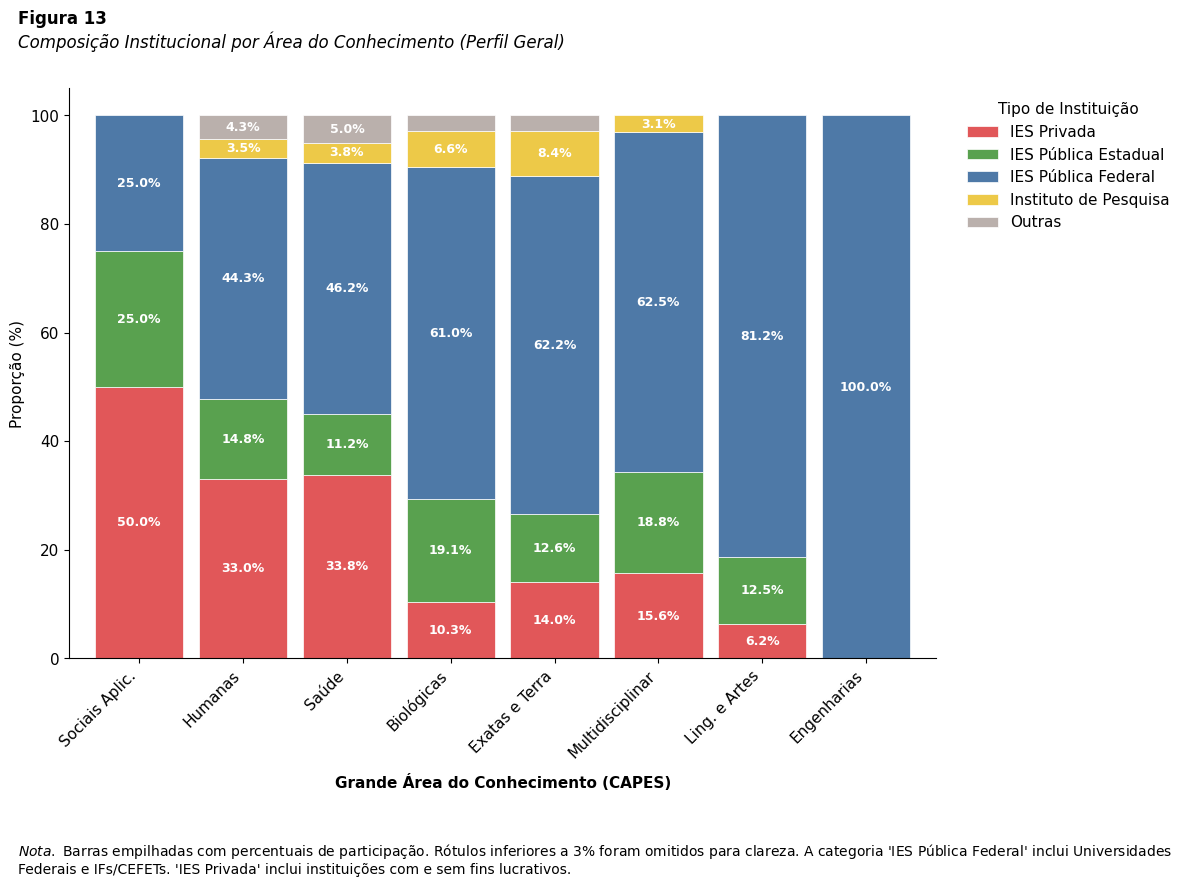

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ==============================================================================
# 1. CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = True
rcParams['axes.spines.bottom'] = True
rcParams['axes.edgecolor'] = 'black'
rcParams['axes.linewidth'] = 0.8
rcParams['legend.frameon'] = False

# ==============================================================================
# 2. CARREGAMENTO E DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except Exception as e:
    print(f"Erro ao ler arquivo: {e}")
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

# Simplificação de nomes
mapa_areas_pt = {
    'Ciências Exatas e da Terra': 'Exatas e Terra',
    'Ciências Biológicas': 'Biológicas',
    'Engenharias': 'Engenharias',
    'Ciências da Saúde': 'Saúde',
    'Ciências Agrárias': 'Agrárias',
    'Ciências Sociais Aplicadas': 'Sociais Aplic.',
    'Ciências Humanas': 'Humanas',
    'Linguística, Letras e Artes': 'Ling. e Artes',
    'Multidisciplinar': 'Multidisciplinar'
}
df['area_plot'] = df[col_area].map(mapa_areas_pt).fillna(df[col_area])

# ==============================================================================
# 3. PLOTAGEM COM RÓTULOS (PORTUGUÊS)
# ==============================================================================
def plot_stacked_labels_pt():
    # Tabela Cruzada (100% empilhada)
    ct = pd.crosstab(df['area_plot'], df[col_inst], normalize='index') * 100

    # Ordenar por "IES Pública Federal" para gradiente visual
    if 'IES Pública Federal' in ct.columns:
        ct = ct.sort_values('IES Pública Federal', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 8))

    # Cores
    colors = {
        'IES Pública Federal': '#4e79a7',
        'IES Pública Estadual': '#59a14f',
        'IES Privada': '#e15759',
        'Instituto de Pesquisa': '#edc948',
        'Outras': '#bab0ac'
    }
    color_list = [colors.get(c, '#bab0ac') for c in ct.columns]

    # Plot
    ct.plot(kind='bar', stacked=True, width=0.85, color=color_list, ax=ax, edgecolor='white', linewidth=0.5)

    # --- INCLUSÃO DOS RÓTULOS DE DADOS ---
    for c in ax.containers:
        # Cria rótulo apenas se a barra tiver altura > 3% (evita poluição)
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 3 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', weight='bold')

    # Textos e Legenda
    ax.set_xlabel("Grande Área do Conhecimento (CAPES)", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Proporção (%)", fontsize=11)
    plt.xticks(rotation=45, ha='right')

    ax.legend(title="Tipo de Instituição", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    # Cabeçalho e Nota APA
    fig.text(0.02, 0.98, "Figura 13", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Composição Institucional por Área do Conhecimento (Perfil Geral)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Barras empilhadas com percentuais de participação. Rótulos inferiores a 3% foram omitidos para clareza. "
            "A categoria 'IES Pública Federal' inclui Universidades Federais e IFs/CEFETs. "
            "'IES Privada' inclui instituições com e sem fins lucrativos.")
    fig.text(0.02, -0.08, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig13_areas_labels_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando gráfico em Português com Rótulos...")
plot_stacked_labels_pt()

Gerando gráfico em Inglês com Rótulos...


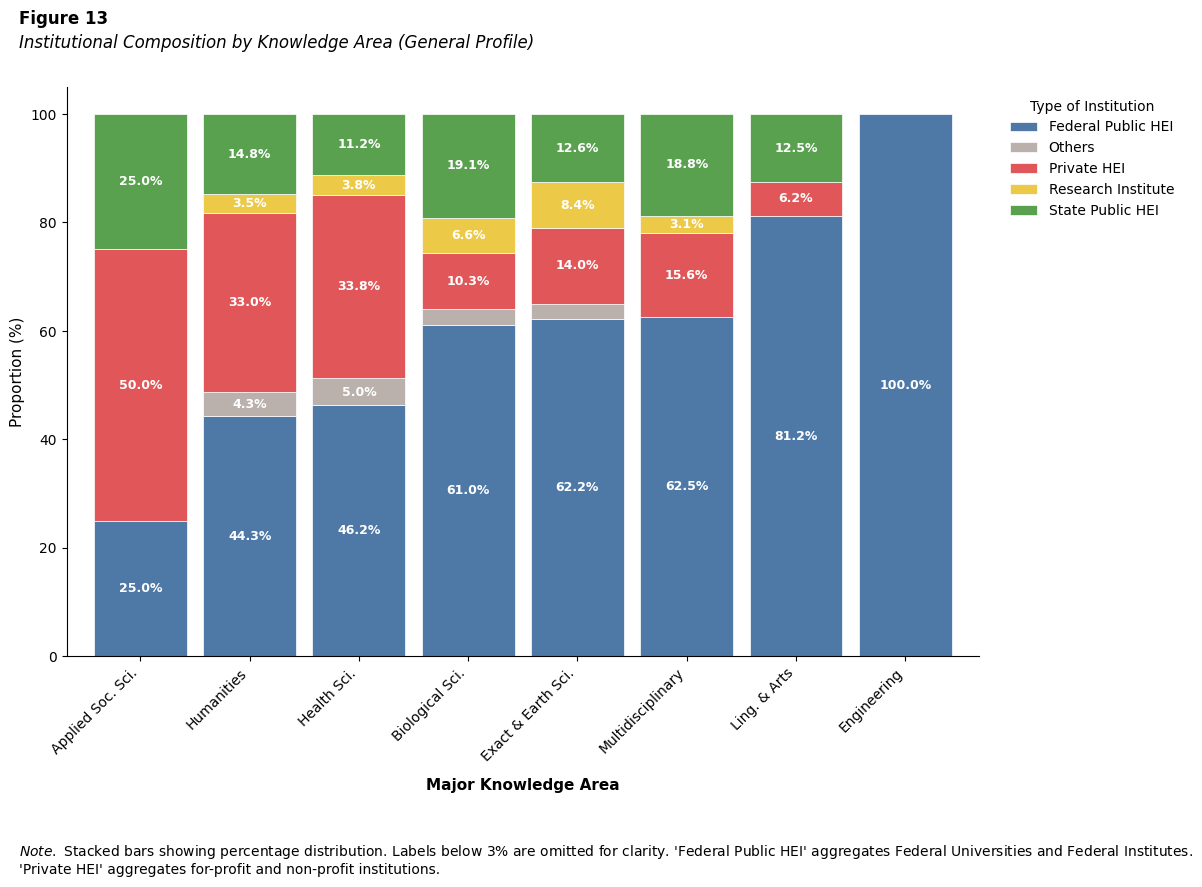

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Configuração
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

# Traduções
mapa_inst_en = {
    'IES Pública Federal': 'Federal Public HEI',
    'IES Pública Estadual': 'State Public HEI',
    'IES Privada': 'Private HEI',
    'Instituto de Pesquisa': 'Research Institute',
    'Outras': 'Others'
}
df['inst_en'] = df[col_inst].map(mapa_inst_en)

mapa_areas_en = {
    'Ciências Exatas e da Terra': 'Exact & Earth Sci.',
    'Ciências Biológicas': 'Biological Sci.',
    'Engenharias': 'Engineering',
    'Ciências da Saúde': 'Health Sci.',
    'Ciências Agrárias': 'Agrarian Sci.',
    'Ciências Sociais Aplicadas': 'Applied Soc. Sci.',
    'Ciências Humanas': 'Humanities',
    'Linguística, Letras e Artes': 'Ling. & Arts',
    'Multidisciplinar': 'Multidisciplinary'
}
df['area_en'] = df[col_area].map(mapa_areas_en).fillna(df[col_area])

# ==============================================================================
# PLOTAGEM COM RÓTULOS (INGLÊS)
# ==============================================================================
def plot_stacked_labels_en():
    ct = pd.crosstab(df['area_en'], df['inst_en'], normalize='index') * 100

    if 'Federal Public HEI' in ct.columns:
        ct = ct.sort_values('Federal Public HEI', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 8))

    colors_en = {
        'Federal Public HEI': '#4e79a7',
        'State Public HEI': '#59a14f',
        'Private HEI': '#e15759',
        'Research Institute': '#edc948',
        'Others': '#bab0ac'
    }
    color_list = [colors_en.get(c, '#bab0ac') for c in ct.columns]

    ct.plot(kind='bar', stacked=True, width=0.85, color=color_list, ax=ax, edgecolor='white', linewidth=0.5)

    # --- INCLUSÃO DOS RÓTULOS DE DADOS ---
    for c in ax.containers:
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 3 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='white', weight='bold')

    ax.set_xlabel("Major Knowledge Area", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Proportion (%)", fontsize=11)
    plt.xticks(rotation=45, ha='right')

    ax.legend(title="Type of Institution", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    fig.text(0.02, 0.98, "Figure 13", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Institutional Composition by Knowledge Area (General Profile)", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ Stacked bars showing percentage distribution. Labels below 3% are omitted for clarity. "
            "'Federal Public HEI' aggregates Federal Universities and Federal Institutes. "
            "'Private HEI' aggregates for-profit and non-profit institutions.")
    fig.text(0.02, -0.08, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig13_areas_labels_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando gráfico em Inglês com Rótulos...")
plot_stacked_labels_en()

Gerando Heatmap PT (Rótulos Ajustados)...


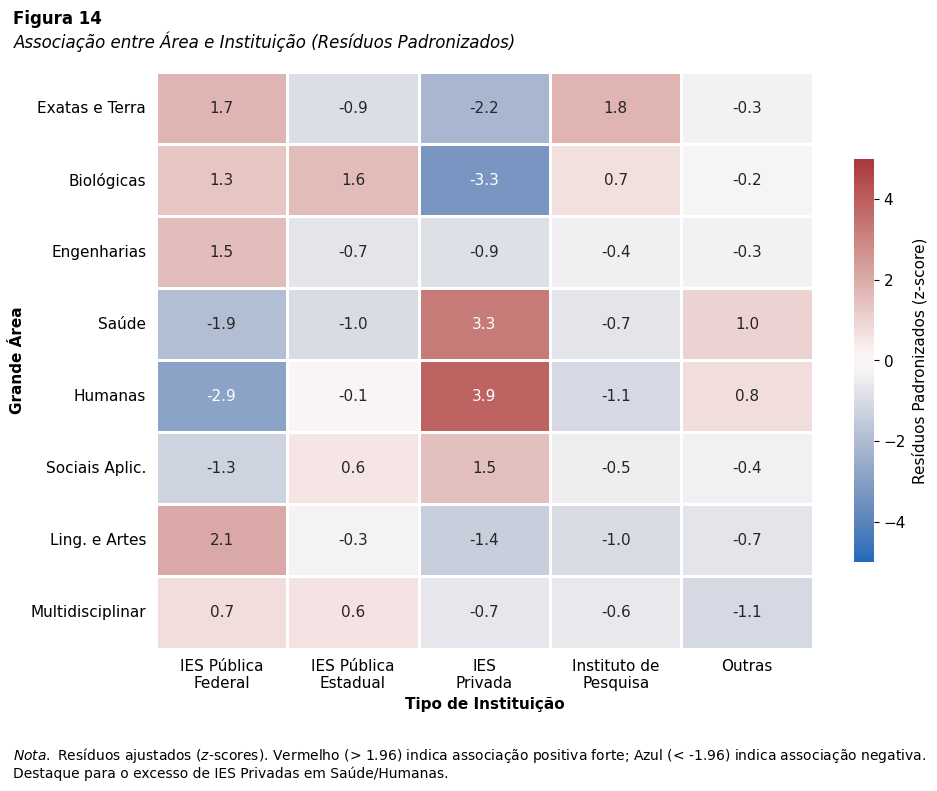

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from matplotlib import rcParams

# Configuração Estética APA 7
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 11
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False
rcParams['legend.frameon'] = False

# Carregamento
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

# Cálculo Resíduos
def get_adj_residuals(data, col_x, col_y):
    ct = pd.crosstab(data[col_y], data[col_x])
    observed = ct.values
    chi2, p, dof, expected = chi2_contingency(observed)

    with np.errstate(divide='ignore', invalid='ignore'):
        n = observed.sum()
        row_p = observed.sum(axis=1) / n
        col_p = observed.sum(axis=0) / n
        div = np.sqrt(expected * (1 - row_p[:, np.newaxis]) * (1 - col_p[np.newaxis, :]))
        adj_res = (observed - expected) / div

    return pd.DataFrame(adj_res, index=ct.index, columns=ct.columns).fillna(0)

# PLOTAGEM PT
def plot_heatmap_pt_wrapped():
    # Mapeamento com Quebra de Linha (\n)
    mapa_inst_pt = {
        'IES Pública Federal': 'IES Pública\nFederal',
        'IES Pública Estadual': 'IES Pública\nEstadual',
        'IES Privada': 'IES\nPrivada',
        'Instituto de Pesquisa': 'Instituto de\nPesquisa',
        'Outras': 'Outras'
    }

    mapa_areas_pt = {
        'Ciências Exatas e da Terra': 'Exatas e Terra',
        'Ciências Biológicas': 'Biológicas',
        'Engenharias': 'Engenharias',
        'Ciências da Saúde': 'Saúde',
        'Ciências Agrárias': 'Agrárias',
        'Ciências Sociais Aplicadas': 'Sociais Aplic.',
        'Ciências Humanas': 'Humanas',
        'Linguística, Letras e Artes': 'Ling. e Artes',
        'Multidisciplinar': 'Multidisciplinar'
    }

    df['area_pt'] = df[col_area].map(mapa_areas_pt)
    df['inst_pt_wrap'] = df[col_inst].map(mapa_inst_pt)

    residuos = get_adj_residuals(df, 'inst_pt_wrap', 'area_pt')

    # Reordenar para consistência
    ordem_areas = ['Exatas e Terra', 'Biológicas', 'Engenharias', 'Agrárias', 'Saúde', 'Humanas', 'Sociais Aplic.', 'Ling. e Artes', 'Multidisciplinar']
    ordem_areas = [a for a in ordem_areas if a in residuos.index]

    # Ordem das colunas (Instituições)
    ordem_inst = ['IES Pública\nFederal', 'IES Pública\nEstadual', 'IES\nPrivada', 'Instituto de\nPesquisa', 'Outras']
    ordem_inst = [i for i in ordem_inst if i in residuos.columns]

    residuos = residuos.reindex(index=ordem_areas, columns=ordem_inst)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(residuos, annot=True, fmt=".1f", cmap="vlag", center=0, vmin=-5, vmax=5,
                linewidths=1, linecolor='white', cbar_kws={'label': 'Resíduos Padronizados (z-score)', 'shrink': 0.7}, ax=ax)

    ax.set_xlabel("Tipo de Instituição", weight='bold', fontsize=11)
    ax.set_ylabel("Grande Área", weight='bold', fontsize=11)
    ax.tick_params(left=False, bottom=False)

    # RÓTULOS HORIZONTAIS E CENTRALIZADOS
    plt.xticks(rotation=0, ha='center')

    fig.text(0.02, 0.96, "Figura 14", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Associação entre Área e Instituição (Resíduos Padronizados)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Resíduos ajustados ($z$-scores). Vermelho (> 1.96) indica associação positiva forte; "
            "Azul (< -1.96) indica associação negativa. Destaque para o excesso de IES Privadas em Saúde/Humanas.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("apa_fig14_heatmap_areas_PT_wrapped.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Heatmap PT (Rótulos Ajustados)...")
plot_heatmap_pt_wrapped()


Gerando Heatmap EN (Rótulos Ajustados)...


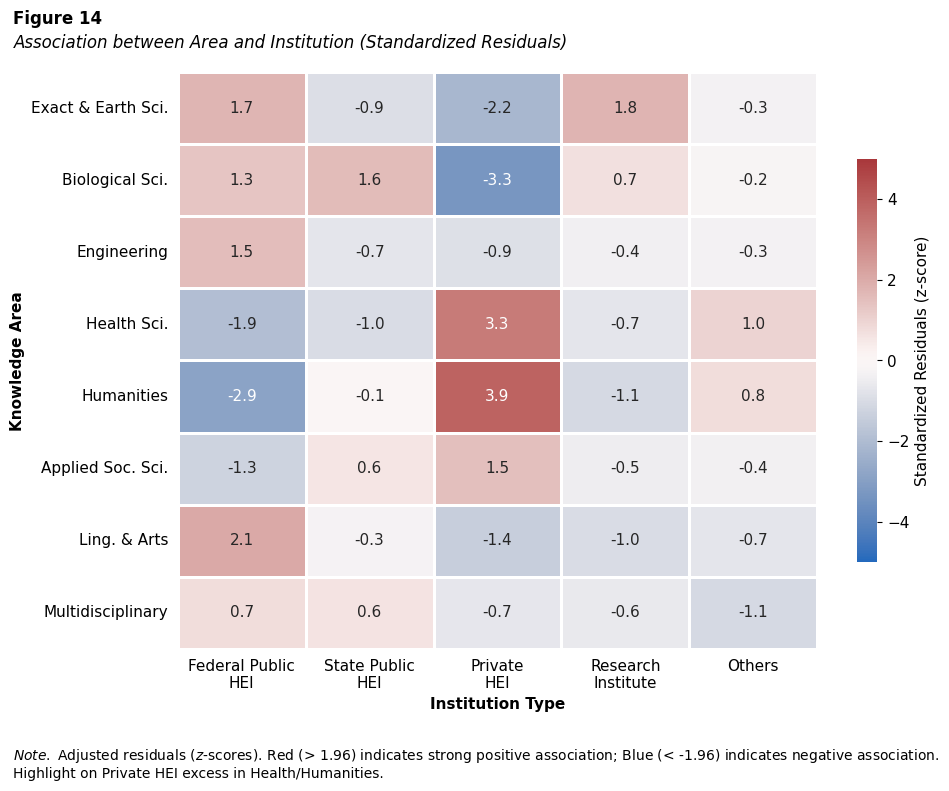

In [10]:
# PLOTAGEM EN
def plot_heatmap_en_wrapped():
    # Mapeamento com Quebra de Linha Manual
    mapa_inst_en = {
        'IES Pública Federal': 'Federal Public\nHEI',
        'IES Pública Estadual': 'State Public\nHEI',
        'IES Privada': 'Private\nHEI',
        'Instituto de Pesquisa': 'Research\nInstitute',
        'Outras': 'Others'
    }

    mapa_areas_en = {
        'Ciências Exatas e da Terra': 'Exact & Earth Sci.',
        'Ciências Biológicas': 'Biological Sci.',
        'Engenharias': 'Engineering',
        'Ciências da Saúde': 'Health Sci.',
        'Ciências Agrárias': 'Agrarian Sci.',
        'Ciências Sociais Aplicadas': 'Applied Soc. Sci.',
        'Ciências Humanas': 'Humanities',
        'Linguística, Letras e Artes': 'Ling. & Arts',
        'Multidisciplinar': 'Multidisciplinary'
    }

    df['area_en'] = df[col_area].map(mapa_areas_en)
    df['inst_en_wrap'] = df[col_inst].map(mapa_inst_en)

    residuos = get_adj_residuals(df, 'inst_en_wrap', 'area_en')

    # Ordenação
    ordem_areas = ['Exact & Earth Sci.', 'Biological Sci.', 'Engineering', 'Agrarian Sci.', 'Health Sci.', 'Humanities', 'Applied Soc. Sci.', 'Ling. & Arts', 'Multidisciplinary']
    ordem_areas = [a for a in ordem_areas if a in residuos.index]

    ordem_inst = ['Federal Public\nHEI', 'State Public\nHEI', 'Private\nHEI', 'Research\nInstitute', 'Others']
    ordem_inst = [i for i in ordem_inst if i in residuos.columns]

    residuos = residuos.reindex(index=ordem_areas, columns=ordem_inst)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(residuos, annot=True, fmt=".1f", cmap="vlag", center=0, vmin=-5, vmax=5,
                linewidths=1, linecolor='white', cbar_kws={'label': 'Standardized Residuals (z-score)', 'shrink': 0.7}, ax=ax)

    ax.set_xlabel("Institution Type", weight='bold', fontsize=11)
    ax.set_ylabel("Knowledge Area", weight='bold', fontsize=11)
    ax.tick_params(left=False, bottom=False)

    # RÓTULOS HORIZONTAIS E CENTRALIZADOS
    plt.xticks(rotation=0, ha='center')

    fig.text(0.02, 0.96, "Figure 14", fontsize=12, weight='bold')
    fig.text(0.02, 0.93, "Association between Area and Institution (Standardized Residuals)", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ Adjusted residuals ($z$-scores). Red (> 1.96) indicates strong positive association; "
            "Blue (< -1.96) indicates negative association. Highlight on Private HEI excess in Health/Humanities.")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("apa_fig14_heatmap_areas_EN_wrapped.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Heatmap EN (Rótulos Ajustados)...")
plot_heatmap_en_wrapped()

Gerando Grouped Bars Refinado (PT)...


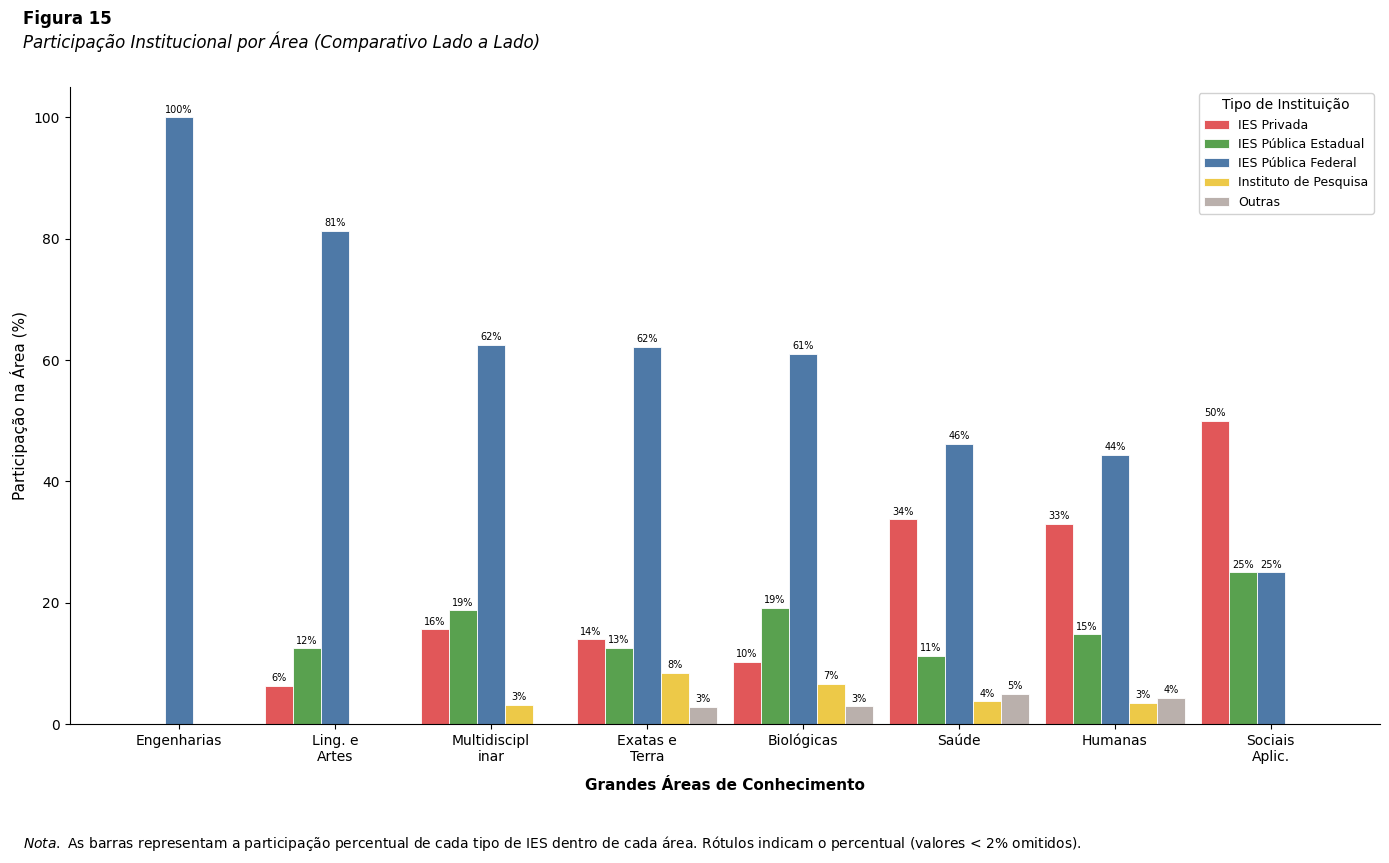

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import textwrap

# ==============================================================================
# CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 10
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = True # Moldura na legenda interna ajuda a ler sobre as barras
rcParams['legend.framealpha'] = 0.9
rcParams['legend.facecolor'] = 'white'

# ==============================================================================
# DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

# Simplificação de nomes PT
mapa_areas_pt = {
    'Ciências Exatas e da Terra': 'Exatas e Terra',
    'Ciências Biológicas': 'Biológicas',
    'Engenharias': 'Engenharias',
    'Ciências da Saúde': 'Saúde',
    'Ciências Agrárias': 'Agrárias',
    'Ciências Sociais Aplicadas': 'Sociais Aplic.',
    'Ciências Humanas': 'Humanas',
    'Linguística, Letras e Artes': 'Ling. e Artes',
    'Multidisciplinar': 'Multidisciplinar'
}
df['area_plot'] = df[col_area].map(mapa_areas_pt).fillna(df[col_area])

# Função para quebrar texto (Wrap)
def wrap_labels(labels, width=10):
    return [textwrap.fill(label, width) for label in labels]

# ==============================================================================
# PLOTAGEM (PORTUGUÊS)
# ==============================================================================
def plot_dodged_refined_pt():
    # Tabela Cruzada
    ct = pd.crosstab(df['area_plot'], df[col_inst], normalize='index') * 100

    # Ordenação (opcional, por Federais)
    if 'IES Pública Federal' in ct.columns:
        ct = ct.sort_values('IES Pública Federal', ascending=False)

    fig, ax = plt.subplots(figsize=(14, 8))

    # Cores
    colors = {
        'IES Pública Federal': '#4e79a7',
        'IES Pública Estadual': '#59a14f',
        'IES Privada': '#e15759',
        'Instituto de Pesquisa': '#edc948',
        'Outras': '#bab0ac'
    }
    color_list = [colors.get(c, '#bab0ac') for c in ct.columns]

    # Plot Grouped Bars
    ct.plot(kind='bar', width=0.90, color=color_list, ax=ax, edgecolor='white', linewidth=0.6)

    # Rótulos nas Barras (Pequenos)
    for c in ax.containers:
        # Mostra apenas se > 2% para evitar sobreposição excessiva
        labels = [f'{v.get_height():.0f}%' if v.get_height() > 2 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='edge', fontsize=7, padding=2, rotation=0)

    # Eixos e Títulos
    ax.set_xlabel("Grandes Áreas de Conhecimento", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Participação na Área (%)", fontsize=11)

    # Eixo X Horizontal e Quebrado
    labels_wrapped = wrap_labels(labels=[l.get_text() for l in ax.get_xticklabels()], width=12)
    ax.set_xticklabels(labels_wrapped, rotation=0, ha='center', fontsize=10)

    # Legenda Interna
    # loc='best' tenta achar o espaço vazio. ncol=2 ajuda a ficar mais horizontal se precisar.
    ax.legend(title="Tipo de Instituição", loc='upper right', ncol=1, fontsize=9)

    # Cabeçalho e Nota
    fig.text(0.02, 0.98, "Figura 15", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Participação Institucional por Área (Comparativo Lado a Lado)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ As barras representam a participação percentual de cada tipo de IES dentro de cada área. "
            "Rótulos indicam o percentual (valores < 2% omitidos).")
    fig.text(0.02, -0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig15_dodged_refined_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Grouped Bars Refinado (PT)...")
plot_dodged_refined_pt()

Gerando Grouped Bars Refinado (EN - Ordem Idêntica)...


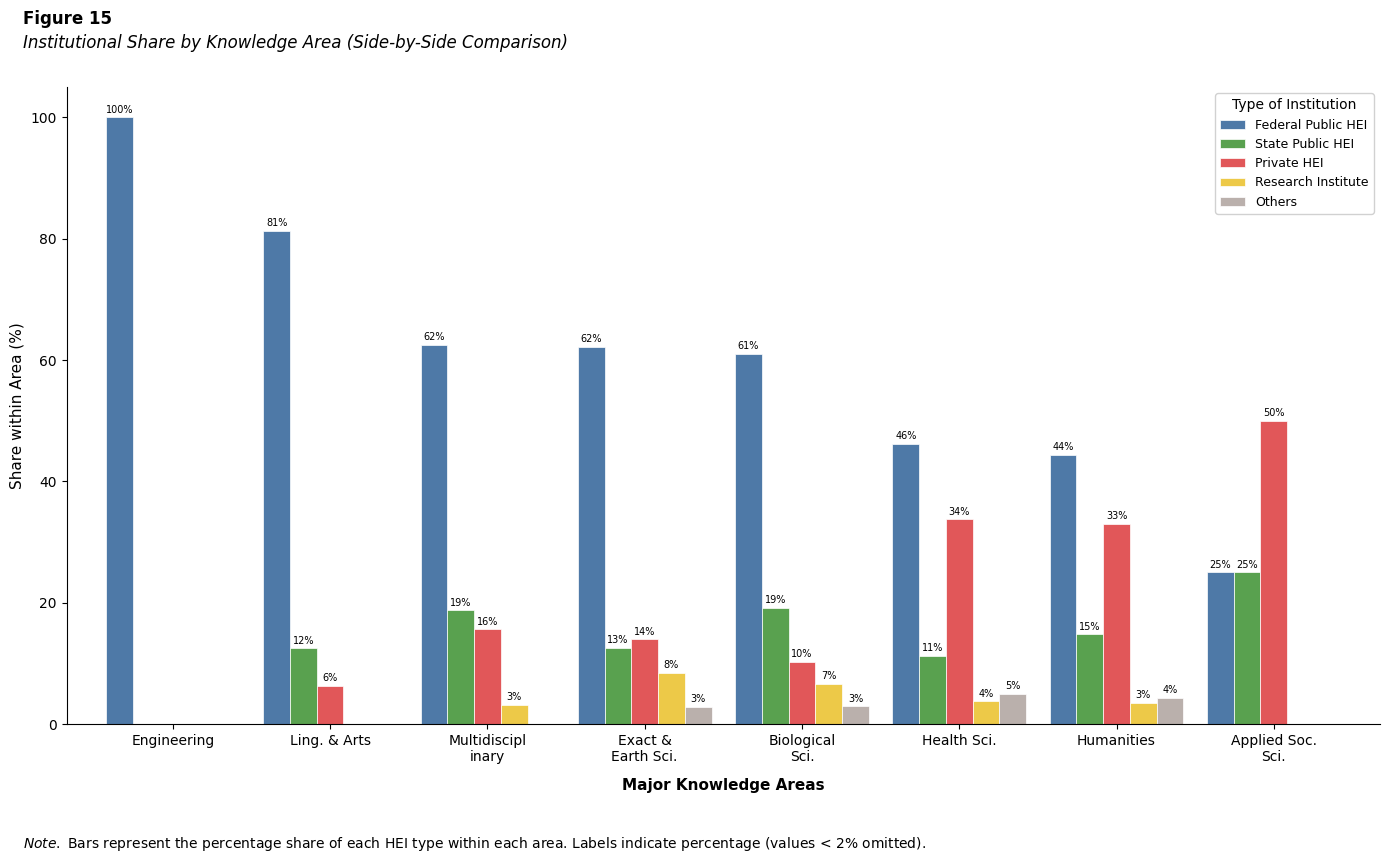

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import textwrap

# ==============================================================================
# CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 10
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = True
rcParams['legend.framealpha'] = 0.9
rcParams['legend.facecolor'] = 'white'

# ==============================================================================
# DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

# Traduções
mapa_inst_en = {
    'IES Pública Federal': 'Federal Public HEI',
    'IES Pública Estadual': 'State Public HEI',
    'IES Privada': 'Private HEI',
    'Instituto de Pesquisa': 'Research Institute',
    'Outras': 'Others'
}
df['inst_en'] = df[col_inst].map(mapa_inst_en)

mapa_areas_en = {
    'Ciências Exatas e da Terra': 'Exact & Earth Sci.',
    'Ciências Biológicas': 'Biological Sci.',
    'Engenharias': 'Engineering',
    'Ciências da Saúde': 'Health Sci.',
    'Ciências Agrárias': 'Agrarian Sci.',
    'Ciências Sociais Aplicadas': 'Applied Soc. Sci.',
    'Ciências Humanas': 'Humanities',
    'Linguística, Letras e Artes': 'Ling. & Arts',
    'Multidisciplinar': 'Multidisciplinary'
}
df['area_en'] = df[col_area].map(mapa_areas_en).fillna(df[col_area])

def wrap_labels(labels, width=12):
    return [textwrap.fill(label, width) for label in labels]

# ==============================================================================
# PLOTAGEM (INGLÊS - ORDEM FORÇADA)
# ==============================================================================
def plot_dodged_refined_en_fixed():
    # 1. Criar Crosstab
    ct = pd.crosstab(df['area_en'], df['inst_en'], normalize='index') * 100

    # 2. FORÇAR A ORDEM DAS COLUNAS (INSTITUIÇÕES) IGUAL AO PT
    # Ordem desejada: Federal -> Estadual -> Privada -> Instituto -> Outras
    desired_order_inst = ['Federal Public HEI', 'State Public HEI', 'Private HEI', 'Research Institute', 'Others']
    # Filtrar apenas as colunas que existem nos dados para evitar erro
    desired_order_inst = [c for c in desired_order_inst if c in ct.columns]
    ct = ct[desired_order_inst]

    # 3. FORÇAR A ORDEM DAS LINHAS (ÁREAS) IGUAL AO PT
    # Ordenar por 'Federal Public HEI' decrescente
    if 'Federal Public HEI' in ct.columns:
        ct = ct.sort_values('Federal Public HEI', ascending=False)

    fig, ax = plt.subplots(figsize=(14, 8))

    # Cores (Mapeadas exatamente para as chaves em Inglês)
    colors_en = {
        'Federal Public HEI': '#4e79a7',   # Azul
        'State Public HEI': '#59a14f',     # Verde
        'Private HEI': '#e15759',          # Vermelho
        'Research Institute': '#edc948',   # Amarelo
        'Others': '#bab0ac'                # Cinza
    }
    color_list = [colors_en.get(c, '#bab0ac') for c in ct.columns]

    # Plot
    ct.plot(kind='bar', width=0.85, color=color_list, ax=ax, edgecolor='white', linewidth=0.5)

    # Rótulos nas Barras
    for c in ax.containers:
        labels = [f'{v.get_height():.0f}%' if v.get_height() > 2 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='edge', fontsize=7, padding=2, rotation=0)

    # Eixos e Títulos
    ax.set_xlabel("Major Knowledge Areas", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Share within Area (%)", fontsize=11)

    # Rótulos Eixo X (Quebrados e Horizontais)
    labels_wrapped = wrap_labels([l.get_text() for l in ax.get_xticklabels()], width=12)
    ax.set_xticklabels(labels_wrapped, rotation=0, ha='center', fontsize=10)

    # Legenda Interna
    ax.legend(title="Type of Institution", loc='upper right', ncol=1, fontsize=9)

    # Cabeçalho e Nota
    fig.text(0.02, 0.98, "Figure 15", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Institutional Share by Knowledge Area (Side-by-Side Comparison)", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ Bars represent the percentage share of each HEI type within each area. "
            "Labels indicate percentage (values < 2% omitted).")
    fig.text(0.02, -0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("apa_fig15_dodged_refined_EN_fixed.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Grouped Bars Refinado (EN - Ordem Idêntica)...")
plot_dodged_refined_en_fixed()

Gerando Mosaico Colorido (PT)...


/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/mosaicplot.py:651: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Rect = Rectangle((x, y), w, h, label=text, **props)


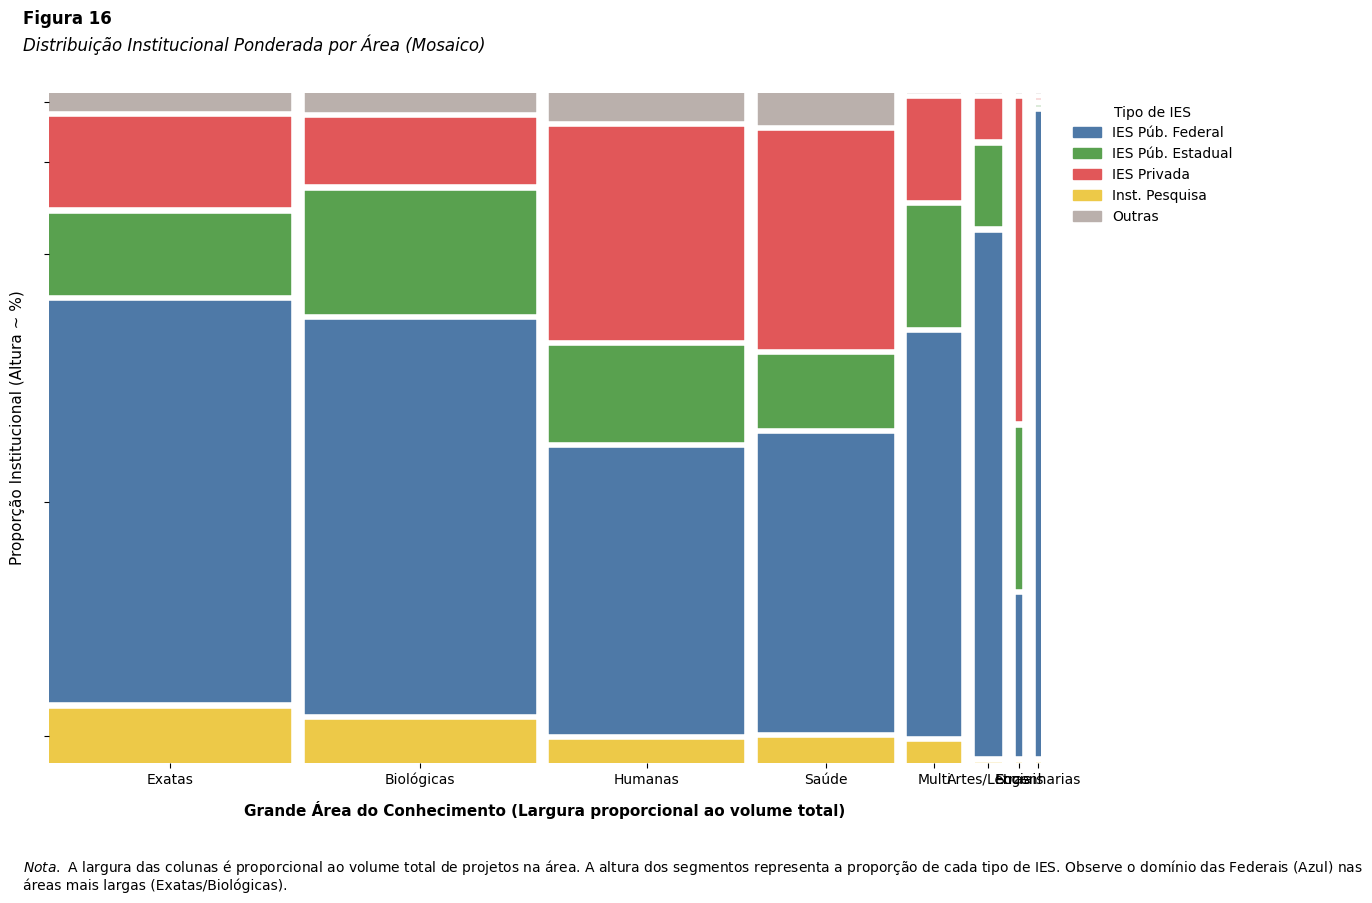

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.patches as mpatches
from matplotlib import rcParams

# ==============================================================================
# CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 10
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.left'] = False
rcParams['axes.spines.bottom'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

# Mapeamentos PT
mapa_inst_pt = {
    'IES Pública Federal': 'IES Púb. Federal',
    'IES Pública Estadual': 'IES Púb. Estadual',
    'IES Privada': 'IES Privada',
    'Instituto de Pesquisa': 'Inst. Pesquisa',
    'Outras': 'Outras'
}

mapa_areas_pt = {
    'Ciências Exatas e da Terra': 'Exatas',
    'Ciências Biológicas': 'Biológicas',
    'Engenharias': 'Engenharias',
    'Ciências da Saúde': 'Saúde',
    'Ciências Agrárias': 'Agrárias',
    'Ciências Sociais Aplicadas': 'Sociais',
    'Ciências Humanas': 'Humanas',
    'Linguística, Letras e Artes': 'Artes/Letras',
    'Multidisciplinar': 'Multi'
}

df['inst_pt'] = df[col_inst].map(mapa_inst_pt)
df['area_pt'] = df[col_area].map(mapa_areas_pt).fillna(df[col_area])

# Cores
colors = {
    'IES Púb. Federal': '#4e79a7',
    'IES Púb. Estadual': '#59a14f',
    'IES Privada': '#e15759',
    'Inst. Pesquisa': '#edc948',
    'Outras': '#bab0ac'
}

# ==============================================================================
# PLOTAGEM (PORTUGUÊS)
# ==============================================================================
def plot_mosaic_pt():
    # Ordenar áreas por volume (decrescente)
    area_counts = df['area_pt'].value_counts().sort_values(ascending=False)
    order_areas = area_counts.index.tolist()

    # Criar DF ordenado para o plot
    df_plot = df.copy()
    df_plot['area_pt'] = pd.Categorical(df_plot['area_pt'], categories=order_areas, ordered=True)
    df_plot = df_plot.sort_values('area_pt')

    # Função de cor
    def props(key):
        return {'color': colors.get(key[1], '#bab0ac'), 'edgecolor': 'white', 'linewidth': 0.3}

    fig, ax = plt.subplots(figsize=(14, 9))

    # Mosaic
    mosaic(df_plot, index=['area_pt', 'inst_pt'], ax=ax, properties=props, gap=0.015, labelizer=lambda k: "")

    # Eixos
    ax.set_xlabel("Grande Área do Conhecimento (Largura proporcional ao volume total)", weight='bold', fontsize=11, labelpad=10)
    ax.set_ylabel("Proporção Institucional (Altura ~ %)", fontsize=11, labelpad=10)

    # Ajuste rótulos eixo X
    for label in ax.get_xticklabels():
        label.set_rotation(0)

    # Remove rótulos eixo Y (limpeza)
    ax.set_yticklabels([])

    # Legenda Manual
    patches = [mpatches.Patch(color=colors[l], label=l) for l in colors.keys()]
    ax.legend(handles=patches, title="Tipo de IES", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

    # Texto APA
    fig.text(0.02, 0.98, "Figura 16", fontsize=12, weight='bold')
    fig.text(0.02, 0.95, "Distribuição Institucional Ponderada por Área (Mosaico)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ A largura das colunas é proporcional ao volume total de projetos na área. "
            "A altura dos segmentos representa a proporção de cada tipo de IES. "
            "Observe o domínio das Federais (Azul) nas áreas mais largas (Exatas/Biológicas).")
    fig.text(0.02, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 0.9, 0.92])
    plt.savefig("apa_fig16_mosaic_colored_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Mosaico Colorido (PT)...")
plot_mosaic_pt()

Gerando Donuts Layout 3x2 (PT)...


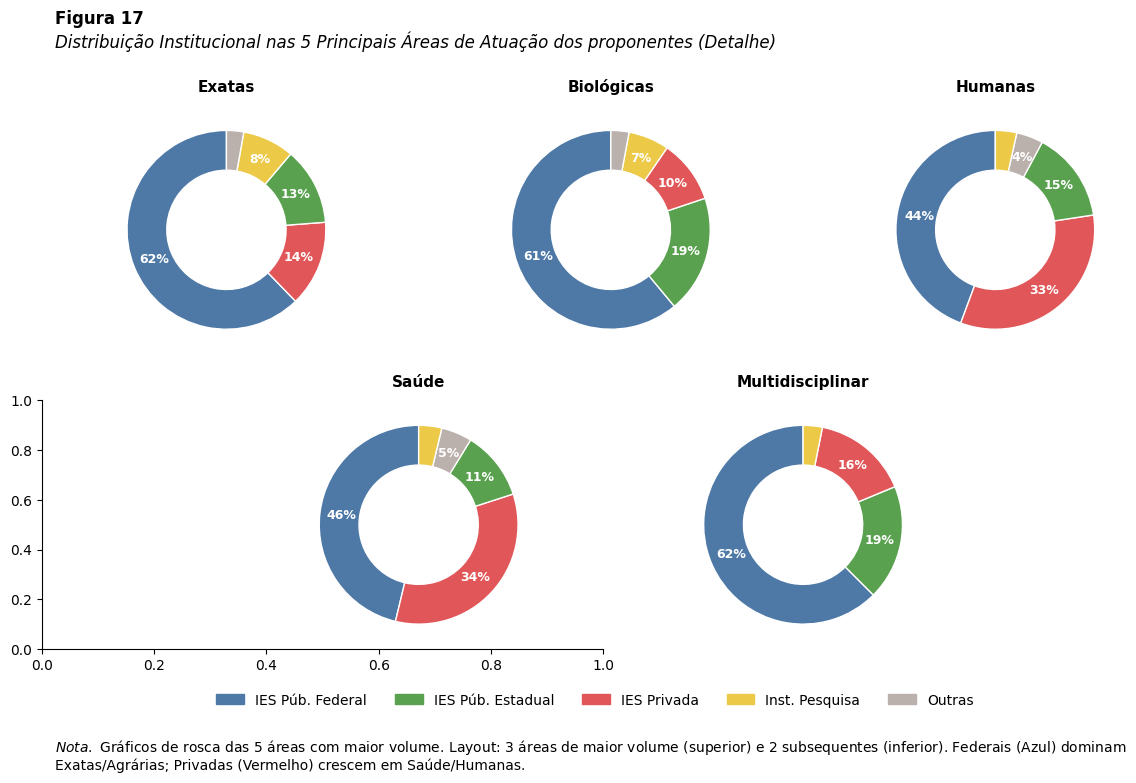

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.gridspec as gridspec # Biblioteca para layouts complexos

# Configuração Estética
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# Dados
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

# Filtrar Top 5
top_5_areas = df[col_area].value_counts().nlargest(5).index.tolist()
df_top = df[df[col_area].isin(top_5_areas)].copy()

# Mapeamentos
mapa_inst_pt = {
    'IES Pública Federal': 'IES Púb. Federal',
    'IES Pública Estadual': 'IES Púb. Estadual',
    'IES Privada': 'IES Privada',
    'Instituto de Pesquisa': 'Inst. Pesquisa',
    'Outras': 'Outras'
}
mapa_areas_short = {
    'Ciências Exatas e da Terra': 'Exatas',
    'Ciências Biológicas': 'Biológicas',
    'Engenharias': 'Engenharias',
    'Ciências da Saúde': 'Saúde',
    'Ciências Agrárias': 'Agrárias',
    'Ciências Sociais Aplicadas': 'Sociais',
    'Ciências Humanas': 'Humanas',
    'Linguística, Letras e Artes': 'Ling/Artes',
    'Multidisciplinar': 'Multidisciplinar'
}
df_top['inst_pt'] = df_top[col_inst].map(mapa_inst_pt)
df_top['area_short'] = df_top[col_area].map(mapa_areas_short)

colors = {
    'IES Púb. Federal': '#4e79a7', 'IES Púb. Estadual': '#59a14f',
    'IES Privada': '#e15759', 'Inst. Pesquisa': '#edc948', 'Outras': '#bab0ac'
}

# ==============================================================================
# PLOTAGEM COM LAYOUT PERSONALIZADO
# ==============================================================================
def plot_donuts_layout_pt():
    # Definir Figura e Grid
    fig = plt.figure(figsize=(12, 8)) # Mais quadrado agora

    # Criar uma grade de 2 linhas x 6 colunas invisíveis para posicionar os gráficos
    # Por que 6? Porque 6 é divisível por 3 (linha de cima) e por 2 (linha de baixo)
    gs = gridspec.GridSpec(2, 6, figure=fig)

    # Definir onde cada gráfico vai ficar:
    # Linha 0: Ocupa 2 colunas cada (Total 6) -> 3 Gráficos
    ax1 = fig.add_subplot(gs[0, 0:2]) # Top Esquerda
    ax2 = fig.add_subplot(gs[0, 2:4]) # Top Centro
    ax3 = fig.add_subplot(gs[0, 4:6]) # Top Direita

    # Linha 1: Ocupa 3 colunas cada (Total 6) -> 2 Gráficos Centralizados
    ax4 = fig.add_subplot(gs[1, 0:3]) # Bottom Esquerda (Centralizado na metade esq)
    # Ajuste fino: para centralizar visualmente, podemos usar offsets ou criar eixos específicos
    # Vamos usar uma divisão mais simples: Bottom Left e Bottom Right centralizados
    # Um jeito melhor para 2 gráficos centralizados embaixo:
    ax4 = fig.add_subplot(gs[1, 1:3]) # Bottom Esquerda (deslocado para o centro)
    ax5 = fig.add_subplot(gs[1, 3:5]) # Bottom Direita (deslocado para o centro)

    axes = [ax1, ax2, ax3, ax4, ax5]
    areas_ordered = df_top['area_short'].value_counts().index.tolist()

    for i, area in enumerate(areas_ordered):
        ax = axes[i]
        subset = df_top[df_top['area_short'] == area]
        counts = subset['inst_pt'].value_counts()

        # --- ONDE MEXER MANUALMENTE NOS RÓTULOS ---
        wedges, texts, autotexts = ax.pie(
            counts.values,
            autopct=lambda p: f'{p:.0f}%' if p > 4 else '', # Texto automático (esconde <4%)
            startangle=90,
            colors=[colors.get(l, '#bab0ac') for l in counts.index],
            wedgeprops=dict(width=0.4, edgecolor='white'),

            # 1. POSIÇÃO RADIAL (Distância do Centro)
            pctdistance=0.78, # <--- AJUSTE AQUI (0.0=Centro, 1.0=Borda). Tente 0.85 ou 0.6.

            # 2. ESTILO DO TEXTO
            textprops={'fontsize': 9, 'weight': 'bold', 'color': 'white'}
        )
        ax.set_title(area, fontsize=11, weight='bold', pad=10)

        # Se quiser mover um rótulo específico manualmente (ajuste fino avançado):
        # Ex: Mover o primeiro rótulo um pouco para a direita
        # autotexts[0].set_position((x, y))

    # Legenda e Textos
    patches = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in colors]
    fig.legend(patches, colors.keys(), loc='lower center', ncol=5, frameon=False, bbox_to_anchor=(0.5, 0.08))

    fig.text(0.05, 0.95, "Figura 17", fontsize=12, weight='bold')

    # Título Atualizado
    fig.text(0.05, 0.92, "Distribuição Institucional nas 5 Principais Áreas de Atuação dos proponentes (Detalhe)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ Gráficos de rosca das 5 áreas com maior volume. "
            "Layout: 3 áreas de maior volume (superior) e 2 subsequentes (inferior). "
            "Federais (Azul) dominam Exatas/Agrárias; Privadas (Vermelho) crescem em Saúde/Humanas.")
    fig.text(0.05, 0.02, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.12, 1, 0.90]) # Margens ajustadas para o novo layout
    plt.savefig("apa_fig17_donuts_layout_v2_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Donuts Layout 3x2 (PT)...")
plot_donuts_layout_pt()

Gerando Donuts Compactos com Setas (PT)...


/tmp/ipython-input-1276457942.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.92])


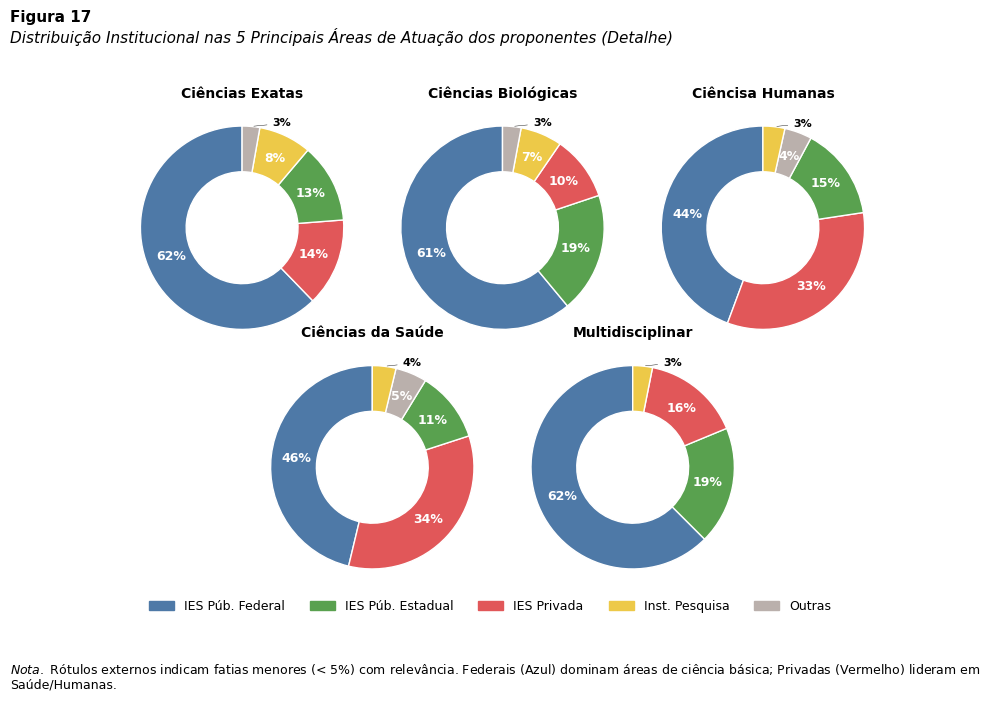

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.gridspec as gridspec

# ==============================================================================
# CONFIGURAÇÃO ESTÉTICA
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

top_5_areas = df[col_area].value_counts().nlargest(5).index.tolist()
df_top = df[df[col_area].isin(top_5_areas)].copy()

mapa_inst_pt = {
    'IES Pública Federal': 'IES Púb. Federal',
    'IES Pública Estadual': 'IES Púb. Estadual',
    'IES Privada': 'IES Privada',
    'Instituto de Pesquisa': 'Inst. Pesquisa',
    'Outras': 'Outras'
}
mapa_areas_short = {
    'Ciências Exatas e da Terra': 'Ciências Exatas', 'Ciências Biológicas': 'Ciências Biológicas',
    'Engenharias': 'Engenharias', 'Ciências da Saúde': 'Ciências da Saúde',
    'Ciências Agrárias': 'Agrárias', 'Ciências Sociais Aplicadas': 'Sociais',
    'Ciências Humanas': 'Ciêncisa Humanas', 'Linguística, Letras e Artes': 'Ling/Artes',
    'Multidisciplinar': 'Multidisciplinar'
}
df_top['inst_pt'] = df_top[col_inst].map(mapa_inst_pt)
df_top['area_short'] = df_top[col_area].map(mapa_areas_short)

colors = {
    'IES Púb. Federal': '#4e79a7', 'IES Púb. Estadual': '#59a14f',
    'IES Privada': '#e15759', 'Inst. Pesquisa': '#edc948', 'Outras': '#bab0ac'
}

# ==============================================================================
# FUNÇÃO PARA DESENHAR SETAS E RÓTULOS INTELIGENTES
# ==============================================================================
def smart_labels(ax, wedges, pct_values):
    """
    Desenha rótulos dentro se couber, ou fora com seta se for pequeno.
    """
    for i, p in enumerate(wedges):
        perc = pct_values[i]

        # Ângulo central da fatia
        ang = (p.theta2 - p.theta1)/2. + p.theta1

        # Coordenadas do centro da fatia (para label interno)
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))

        # LÓGICA DE EXIBIÇÃO
        if perc > 3.9:
            # Caso 1: Fatia Grande (>3.9%) -> Texto Branco no Centro
            ax.text(x*0.75, y*0.75, f'{perc:.0f}%',
                    ha='center', va='center', color='white', fontweight='bold', fontsize=9)

        elif perc >= 1.5: # Mostra se for relevante (>1.5%)
            # Caso 2: Fatia Pequena -> Seta para fora

            # Posição da conexão na borda da rosca
            x_edge = x * 1.0
            y_edge = y * 1.0

            # Posição do Texto (mais afastado)
            # Ajuste dinâmico: se estiver na esquerda, joga mais pra esquerda
            horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
            connectionstyle = f"angle,angleA=0,angleB={ang}"

            # Anotação com Seta
            ax.annotate(f'{perc:.0f}%', xy=(x_edge, y_edge), xytext=(0.3*np.sign(x), 1*y),
                        horizontalalignment=horizontalalignment,
                        arrowprops=dict(arrowstyle="-", color='black', lw=0.3),
                        fontsize=8, fontweight='bold', color='black')

# ==============================================================================
# PLOTAGEM COMPACTA (PT)
# ==============================================================================
def plot_compact_pt():
    fig = plt.figure(figsize=(10, 7)) # Figura mais compacta

    # GridSpec com espaçamento reduzido (wspace/hspace)
    gs = gridspec.GridSpec(2, 6, figure=fig, wspace=0.05, hspace=-0.2)
    # hspace negativo aproxima as linhas verticalmente

    ax1 = fig.add_subplot(gs[0, 0:2])
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax3 = fig.add_subplot(gs[0, 4:6])
    ax4 = fig.add_subplot(gs[1, 1:3])
    ax5 = fig.add_subplot(gs[1, 3:5])

    axes = [ax1, ax2, ax3, ax4, ax5]
    areas_ordered = df_top['area_short'].value_counts().index.tolist()

    for i, area in enumerate(areas_ordered):
        ax = axes[i]
        subset = df_top[df_top['area_short'] == area]
        counts = subset['inst_pt'].value_counts()
        total = counts.sum()
        pct_values = (counts.values / total) * 100

        wedges, texts = ax.pie(
            counts.values,
            startangle=90,
            colors=[colors.get(l, '#bab0ac') for l in counts.index],
            wedgeprops=dict(width=0.45, edgecolor='white', linewidth=1) # Width maior para caber número
        )
        ax.set_title(area, fontsize=10, weight='bold', pad=2) # Pad menor aproxima título

        # Aplicar Rótulos com Setas
        smart_labels(ax, wedges, pct_values)

    # Legenda Compacta
    patches = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in colors]
    fig.legend(patches, colors.keys(), loc='lower center', ncol=5, frameon=False,
               bbox_to_anchor=(0.5, 0.1), fontsize=9)

    # Cabeçalho e Nota
    fig.text(0.02, 0.96, "Figura 17", fontsize=11, weight='bold')
    fig.text(0.02, 0.93, "Distribuição Institucional nas 5 Principais Áreas de Atuação dos proponentes (Detalhe)", fontsize=11, style='italic')

    note = (r"$\it{Nota.}$ Rótulos externos indicam fatias menores (< 5%) com relevância. "
            "Federais (Azul) dominam áreas de ciência básica; Privadas (Vermelho) lideram em Saúde/Humanas.")
    fig.text(0.02, 0.01, note, fontsize=9, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("apa_fig17_donuts_compact_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Donuts Compactos com Setas (PT)...")
plot_compact_pt()

Gerando Donuts Compactos com Setas (EN)...


/tmp/ipython-input-2170537905.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.92])


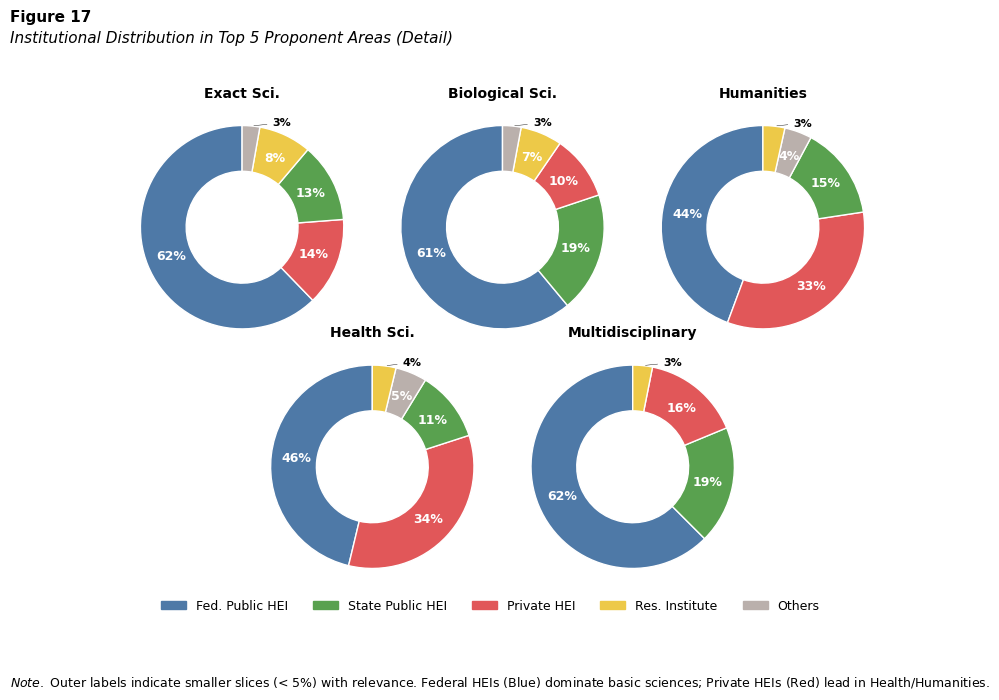

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.gridspec as gridspec

# ==============================================================================
# CONFIGURAÇÃO ESTÉTICA (IGUAL À SUA)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# DADOS E TRADUÇÃO
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

# Filtrar Top 5
top_5_areas = df[col_area].value_counts().nlargest(5).index.tolist()
df_top = df[df[col_area].isin(top_5_areas)].copy()

# Mapeamentos EN
mapa_inst_en = {
    'IES Pública Federal': 'Fed. Public HEI',
    'IES Pública Estadual': 'State Public HEI',
    'IES Privada': 'Private HEI',
    'Instituto de Pesquisa': 'Res. Institute',
    'Outras': 'Others'
}
mapa_areas_short_en = {
    'Ciências Exatas e da Terra': 'Exact Sci.', 'Ciências Biológicas': 'Biological Sci.',
    'Engenharias': 'Eng.', 'Ciências da Saúde': 'Health Sci.',
    'Ciências Agrárias': 'Agrarian Sci.', 'Ciências Sociais Aplicadas': 'Soc. Sci.',
    'Ciências Humanas': 'Humanities', 'Linguística, Letras e Artes': 'Arts/Ling.',
    'Multidisciplinar': 'Multidisciplinary'
}
df_top['inst_en'] = df_top[col_inst].map(mapa_inst_en)
df_top['area_short_en'] = df_top[col_area].map(mapa_areas_short_en)

# Cores Mapeadas para EN
colors_en = {
    'Fed. Public HEI': '#4e79a7', 'State Public HEI': '#59a14f',
    'Private HEI': '#e15759', 'Res. Institute': '#edc948', 'Others': '#bab0ac'
}

# ==============================================================================
# FUNÇÃO SMART LABELS (REPLICANDO SUA LÓGICA EXATA)
# ==============================================================================
def smart_labels(ax, wedges, pct_values):
    """
    Replica a lógica exata ajustada por você: >3.9% interno, setas curtas (0.3, 1.0).
    """
    for i, p in enumerate(wedges):
        perc = pct_values[i]

        # Ângulo
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))

        # LÓGICA DE EXIBIÇÃO
        if perc > 3.9: # Seu ajuste manual
            ax.text(x*0.75, y*0.75, f'{perc:.0f}%',
                    ha='center', va='center', color='white', fontweight='bold', fontsize=9)

        elif perc >= 1.5:
            x_edge = x * 1.0
            y_edge = y * 1.0

            horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]

            # Seus ajustes de posição de seta (xytext)
            ax.annotate(f'{perc:.0f}%', xy=(x_edge, y_edge), xytext=(0.3*np.sign(x), 1*y),
                        horizontalalignment=horizontalalignment,
                        arrowprops=dict(arrowstyle="-", color='black', lw=0.3), # lw=0.3
                        fontsize=8, fontweight='bold', color='black')

# ==============================================================================
# PLOTAGEM COMPACTA (EN)
# ==============================================================================
def plot_compact_en():
    fig = plt.figure(figsize=(10, 7))

    # GridSpec idêntico
    gs = gridspec.GridSpec(2, 6, figure=fig, wspace=0.05, hspace=-0.2)

    ax1 = fig.add_subplot(gs[0, 0:2])
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax3 = fig.add_subplot(gs[0, 4:6])
    ax4 = fig.add_subplot(gs[1, 1:3])
    ax5 = fig.add_subplot(gs[1, 3:5])

    axes = [ax1, ax2, ax3, ax4, ax5]
    areas_ordered = df_top['area_short_en'].value_counts().index.tolist()

    for i, area in enumerate(areas_ordered):
        ax = axes[i]
        subset = df_top[df_top['area_short_en'] == area]
        counts = subset['inst_en'].value_counts()
        total = counts.sum()
        pct_values = (counts.values / total) * 100

        wedges, texts = ax.pie(
            counts.values,
            startangle=90,
            colors=[colors_en.get(l, '#bab0ac') for l in counts.index],
            wedgeprops=dict(width=0.45, edgecolor='white', linewidth=1)
        )
        ax.set_title(area, fontsize=10, weight='bold', pad=2)

        # Aplicar Rótulos
        smart_labels(ax, wedges, pct_values)

    # Legenda Compacta (Posição 0.5, 0.1 conforme seu ajuste)
    patches = [plt.Rectangle((0,0),1,1, color=colors_en[label]) for label in colors_en]
    fig.legend(patches, colors_en.keys(), loc='lower center', ncol=5, frameon=False,
               bbox_to_anchor=(0.5, 0.1), fontsize=9)

    # Cabeçalho e Nota (Traduzidos)
    fig.text(0.02, 0.96, "Figure 17", fontsize=11, weight='bold')
    fig.text(0.02, 0.93, "Institutional Distribution in Top 5 Proponent Areas (Detail)", fontsize=11, style='italic')

    note = (r"$\it{Note.}$ Outer labels indicate smaller slices (< 5%) with relevance. "
            "Federal HEIs (Blue) dominate basic sciences; Private HEIs (Red) lead in Health/Humanities.")
    fig.text(0.02, 0.01, note, fontsize=9, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    plt.savefig("apa_fig17_donuts_compact_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Donuts Compactos com Setas (EN)...")
plot_compact_en()

In [67]:
import pandas as pd
import plotly.graph_objects as go

# ==============================================================================
# DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

# Simplificação de Nomes (PT)
mapa_inst = {
    'IES Pública Federal': 'IES Federal',
    'IES Pública Estadual': 'IES Estadual',
    'IES Privada': 'IES Privada',
    'Instituto de Pesquisa': 'Inst. Pesquisa',
    'Outras': 'Outras'
}
mapa_areas = {
    'Ciências Exatas e da Terra': 'Ciências Exatas',
    'Ciências Biológicas': 'Ciências Biológicas',
    'Engenharias': 'Engenharias',
    'Ciências da Saúde': 'Ciências da Saúde',
    'Ciências Agrárias': 'Ciências Agrárias',
    'Ciências Sociais Aplicadas': 'Ciências Sociais',
    'Ciências Humanas': 'Ciências Humanas',
    'Linguística, Letras e Artes': 'Linguística, Letras e Artes',
    'Multidisciplinar': 'Multidisciplinar'
}

df['source_label'] = df[col_inst].map(mapa_inst)
df['target_label'] = df[col_area].map(mapa_areas).fillna(df[col_area])

# Cores (Hex) para os Nós e Links
# Azul, Verde, Vermelho, Amarelo, Cinza
color_map = {
    'IES Federal': '#4e79a7',
    'IES Estadual': '#59a14f',
    'IES Privada': '#e15759',
    'Inst. Pesquisa': '#edc948',
    'Outras': '#bab0ac'
}
# Para as áreas (destino), usaremos um cinza neutro para não competir,
# ou podemos repetir a cor se quisermos destacar o fluxo. Vamos usar cinza claro nos nós de destino.
node_color_default = '#888888'

# ==============================================================================
# PREPARAÇÃO DO SANKEY
# ==============================================================================
# 1. Agrupar dados (Origem -> Destino : Contagem)
flows = df.groupby(['source_label', 'target_label']).size().reset_index(name='value')

# 2. Criar lista única de nós (labels)
# Ordem: Primeiro as Fontes (IES), depois os Destinos (Áreas) para ficarem organizados
sources_unique = list(color_map.keys()) # Força a ordem das IES
targets_unique = sorted(list(flows['target_label'].unique()))
all_nodes = sources_unique + targets_unique

# Mapear label -> índice numérico (0, 1, 2...)
node_indices = {label: i for i, label in enumerate(all_nodes)}

# 3. Criar listas para o Plotly
source_indices = flows['source_label'].map(node_indices).tolist()
target_indices = flows['target_label'].map(node_indices).tolist()
values = flows['value'].tolist()

# 4. Definir cores dos Nós e dos Links
# Cores dos Nós
node_colors = [color_map.get(label, node_color_default) for label in all_nodes]

# Cores dos Links (Fluxos) - Herdam a cor da Fonte com transparência
link_colors = [color_map.get(row['source_label']) for index, row in flows.iterrows()]
# Adicionar transparência (opacity 0.4) ao hex para ficar elegante
def hex_to_rgba(hex_code, alpha=0.4):
    hex_code = hex_code.lstrip('#')
    return f'rgba({int(hex_code[0:2], 16)}, {int(hex_code[2:4], 16)}, {int(hex_code[4:6], 16)}, {alpha})'

link_colors_rgba = [hex_to_rgba(c) for c in link_colors]

# ==============================================================================
# PLOTAGEM (PLOTLY)
# ==============================================================================
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="white", width=0.5),
        label=all_nodes,
        color=node_colors
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=values,
        color=link_colors_rgba
    )
)])

# Layout Estilo APA
fig.update_layout(
    title_text="<b>Figura 18</b><br><i>Fluxo Institucional dos Proponentes para suas Respectivas Áreas do Conhecimento.</i>",
    title_font_size=14,
    font_family="Arial",
    font_size=12,
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=600,
    margin=dict(l=50, r=50, t=80, b=50) # Margens
)

# Adicionar Nota de Rodapé como Anotação
fig.add_annotation(
    text="<i>Nota.</i> A largura das faixas representa o volume de projetos. Cores indicam a origem institucional:<br>"
         "Azul=Federal, Verde=Estadual, Vermelho=Privada.",
    xref="paper", yref="paper",
    x=0, y=-0.1, showarrow=False, align="left", font=dict(size=11)
)

fig.show()

In [68]:
import pandas as pd
import plotly.graph_objects as go

# ==============================================================================
# DADOS
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

# Simplificação de Nomes (EN) - Correspondendo à sua versão PT
mapa_inst_en = {
    'IES Pública Federal': 'Federal HEI',
    'IES Pública Estadual': 'State HEI',
    'IES Privada': 'Private HEI',
    'Instituto de Pesquisa': 'Res. Institute',
    'Outras': 'Others'
}
mapa_areas_en = {
    'Ciências Exatas e da Terra': 'Exact Sciences',
    'Ciências Biológicas': 'Biological Sciences',
    'Engenharias': 'Engineering',
    'Ciências da Saúde': 'Health Sciences',
    'Ciências Agrárias': 'Agrarian Sciences',
    'Ciências Sociais Aplicadas': 'Social Sciences',
    'Ciências Humanas': 'Humanities',
    'Linguística, Letras e Artes': 'Linguistics, Letters and Arts',
    'Multidisciplinar': 'Multidisciplinary'
}

df['source_label'] = df[col_inst].map(mapa_inst_en)
df['target_label'] = df[col_area].map(mapa_areas_en).fillna(df[col_area])

# Cores (Hex) - Mesma paleta
color_map = {
    'Federal HEI': '#4e79a7',
    'State HEI': '#59a14f',
    'Private HEI': '#e15759',
    'Res. Institute': '#edc948',
    'Others': '#bab0ac'
}
node_color_default = '#888888'

# ==============================================================================
# PREPARAÇÃO DO SANKEY
# ==============================================================================
flows = df.groupby(['source_label', 'target_label']).size().reset_index(name='value')

sources_unique = list(color_map.keys())
targets_unique = sorted(list(flows['target_label'].unique()))
all_nodes = sources_unique + targets_unique

node_indices = {label: i for i, label in enumerate(all_nodes)}

source_indices = flows['source_label'].map(node_indices).tolist()
target_indices = flows['target_label'].map(node_indices).tolist()
values = flows['value'].tolist()

node_colors = [color_map.get(label, node_color_default) for label in all_nodes]

link_colors = [color_map.get(row['source_label']) for index, row in flows.iterrows()]

def hex_to_rgba(hex_code, alpha=0.4):
    hex_code = hex_code.lstrip('#')
    return f'rgba({int(hex_code[0:2], 16)}, {int(hex_code[2:4], 16)}, {int(hex_code[4:6], 16)}, {alpha})'

link_colors_rgba = [hex_to_rgba(c) for c in link_colors]

# ==============================================================================
# PLOTAGEM (PLOTLY - EN)
# ==============================================================================
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="white", width=0.5),
        label=all_nodes,
        color=node_colors
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=values,
        color=link_colors_rgba
    )
)])

# Layout Estilo APA (Ajustado conforme PT)
fig.update_layout(
    title_text="<b>Figure 18</b><br><i>Institutional Flow of Proponents to their Respective Knowledge Areas.</i>",
    title_font_size=14,
    font_family="Arial",
    font_size=12,
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=600,
    margin=dict(l=50, r=50, t=80, b=50) # Margem inferior ajustada para 50
)

# Adicionar Nota de Rodapé (Posição ajustada para y=-0.1)
fig.add_annotation(
    text="<i>Note.</i> Band width represents project volume. Colors indicate institutional source:<br>"
         "Blue=Federal, Green=State, Red=Private.",
    xref="paper", yref="paper",
    x=0, y=-0.1, showarrow=False, align="left", font=dict(size=11)
)

fig.show()

Gerando Radar Top 5 (PT)...


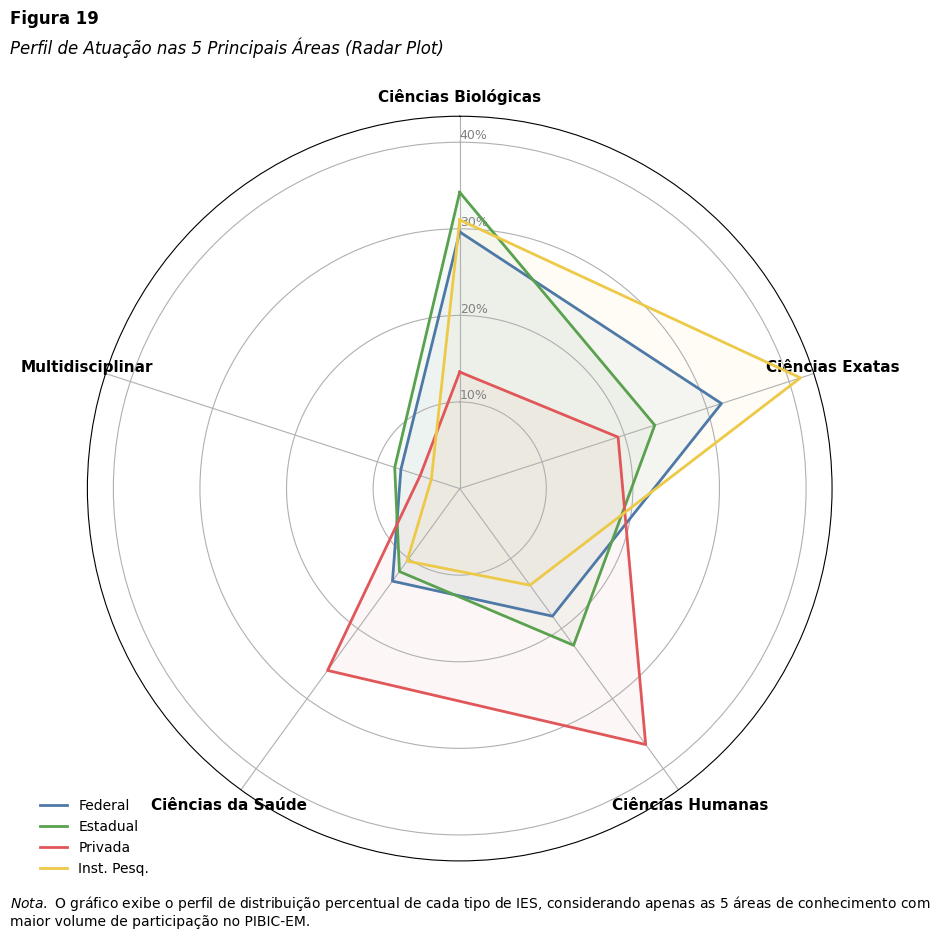

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from math import pi

# ==============================================================================
# CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# DADOS E FILTRAGEM (TOP 5 ÁREAS)
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

# --- FILTRO TOP 5 ÁREAS ---
top_5_areas = df[col_area].value_counts().nlargest(5).index.tolist()
df_filtered = df[df[col_area].isin(top_5_areas)].copy()

# Mapeamentos Curtos (PT)
mapa_inst_pt = {
    'IES Pública Federal': 'Federal',
    'IES Pública Estadual': 'Estadual',
    'IES Privada': 'Privada',
    'Instituto de Pesquisa': 'Inst. Pesq.',
    'Outras': 'Outras'
}
# Mapeamento de áreas (para nomes curtos no gráfico)
mapa_areas_pt = {
    'Ciências Exatas e da Terra': 'Ciências Exatas',
    'Ciências Biológicas': 'Ciências Biológicas',
    'Engenharias': 'Engenharias',
    'Ciências da Saúde': 'Ciências da Saúde',
    'Ciências Agrárias': 'Ciências Agrárias',
    'Ciências Sociais Aplicadas': 'Ciências Sociais',
    'Ciências Humanas': 'Ciências Humanas',
    'Linguística, Letras e Artes': 'Artes/Letras',
    'Multidisciplinar': 'Multidisciplinar'
}

df_filtered['inst_pt'] = df_filtered[col_inst].map(mapa_inst_pt)
df_filtered['area_pt'] = df_filtered[col_area].map(mapa_areas_pt).fillna(df_filtered[col_area])

# Cores (Consistentes)
colors = {
    'Federal': '#4e79a7',
    'Estadual': '#59a14f',
    'Privada': '#e15759',
    'Inst. Pesq.': '#edc948',
    'Outras': '#bab0ac'
}

# ==============================================================================
# PREPARAÇÃO DO RADAR
# ==============================================================================
# Calcular perfil percentual dentro do recorte Top 5
perfil = pd.crosstab(df_filtered['inst_pt'], df_filtered['area_pt'], normalize='index') * 100

# Definir Categorias (Eixos)
categories = list(perfil.columns)
N = len(categories)

# Calcular ângulos
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Fechar o ciclo

# ==============================================================================
# PLOTAGEM
# ==============================================================================
def plot_radar_top5_pt():
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    # Ajuste de rotação e direção
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Eixos X (Categorias)
    plt.xticks(angles[:-1], categories, fontsize=11, weight='bold')

    # Eixo Y (Grid)
    ax.set_rlabel_position(0)
    plt.yticks([10, 20, 30, 40], ["10%", "20%", "30%", "40%"], color="grey", size=9)
    plt.ylim(0, 43) # Ajuste conforme o máximo dos seus dados

    # Plotar cada Instituição (Linhas)
    instituicoes = ['Federal', 'Estadual', 'Privada', 'Inst. Pesq.']

    for inst in instituicoes:
        if inst in perfil.index:
            values = perfil.loc[inst].values.flatten().tolist()
            values += values[:1]
            ax.plot(angles, values, linewidth=2, linestyle='solid', label=inst, color=colors[inst])
            ax.fill(angles, values, color=colors[inst], alpha=0.05) # Preenchimento bem suave

    # Legenda
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), frameon=False, fontsize=10)

    # Textos APA
    fig.text(0.05, 0.95, "Figura 19", fontsize=12, weight='bold')
    fig.text(0.05, 0.92, "Perfil de Atuação nas 5 Principais Áreas (Radar Plot)", fontsize=12, style='italic')

    note = (r"$\it{Nota.}$ O gráfico exibe o perfil de distribuição percentual de cada tipo de IES, considerando apenas "
            "as 5 áreas de conhecimento com maior volume de participação no PIBIC-EM.")
    fig.text(0.05, 0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.90])
    plt.savefig("apa_fig19_radar_top5_PT.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Radar Top 5 (PT)...")
plot_radar_top5_pt()

Gerando Radar Top 5 (EN)...


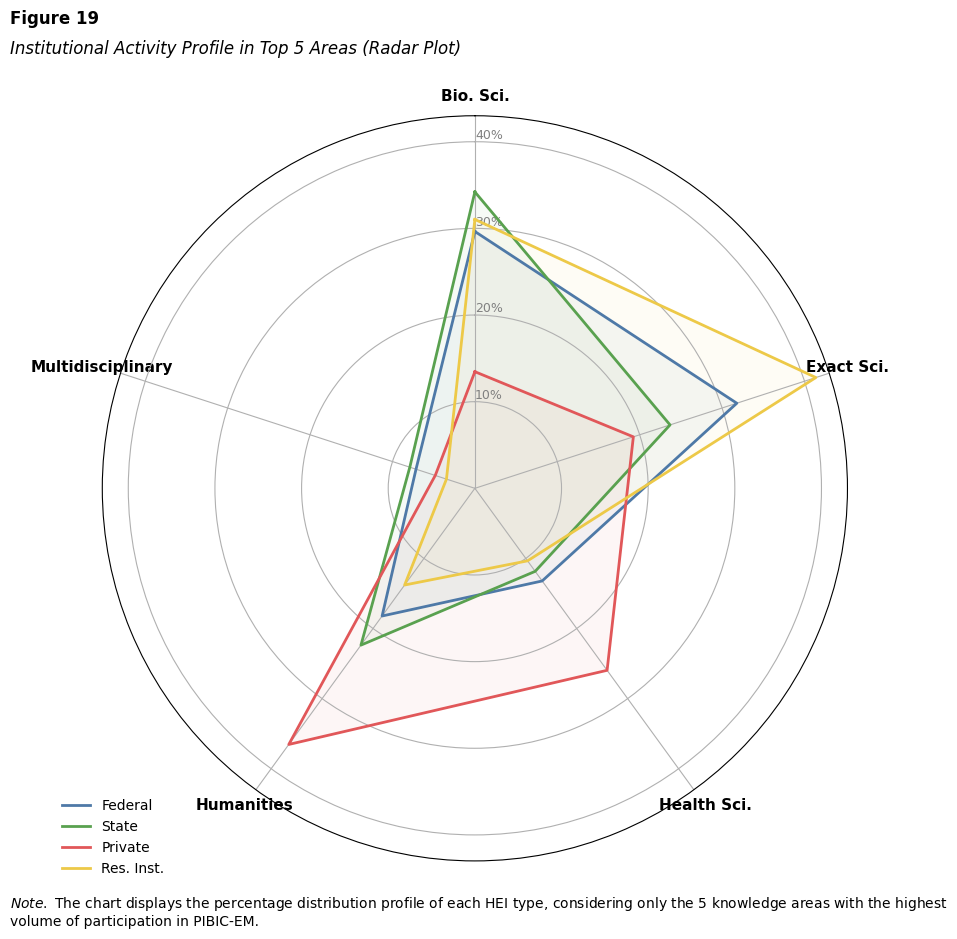

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from math import pi

# ==============================================================================
# CONFIGURAÇÃO ESTÉTICA (APA 7)
# ==============================================================================
plt.rcParams.update(plt.rcParamsDefault)
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['legend.frameon'] = False

# ==============================================================================
# DADOS E FILTRAGEM (TOP 5 ÁREAS)
# ==============================================================================
try:
    nome_arquivo = "2025_11_20_participacao_PIBIC-EM_categoria_adm_corrigida_v4.csv"
    df = pd.read_csv(nome_arquivo)
except:
    df = pd.DataFrame()

col_area = 'grande_area - area_macro_CAPES'
col_inst = 'tipo_ies_corrigido'
df = df[df[col_area] != 'Não aplicável'].dropna(subset=[col_area])

# --- FILTRO TOP 5 ÁREAS ---
top_5_areas = df[col_area].value_counts().nlargest(5).index.tolist()
df_filtered = df[df[col_area].isin(top_5_areas)].copy()

# Mapeamentos Curtos (EN)
mapa_inst_en = {
    'IES Pública Federal': 'Federal',
    'IES Pública Estadual': 'State',
    'IES Privada': 'Private',
    'Instituto de Pesquisa': 'Res. Inst.',
    'Outras': 'Others'
}
# Mapeamento de áreas (para nomes curtos no gráfico)
mapa_areas_en = {
    'Ciências Exatas e da Terra': 'Exact Sci.',
    'Ciências Biológicas': 'Bio. Sci.',
    'Engenharias': 'Eng.',
    'Ciências da Saúde': 'Health Sci.',
    'Ciências Agrárias': 'Agrarian',
    'Ciências Sociais Aplicadas': 'Soc. Sci.',
    'Ciências Humanas': 'Humanities',
    'Linguística, Letras e Artes': 'Arts/Ling.',
    'Multidisciplinar': 'Multidisciplinary'
}

df_filtered['inst_en'] = df_filtered[col_inst].map(mapa_inst_en)
df_filtered['area_en'] = df_filtered[col_area].map(mapa_areas_en).fillna(df_filtered[col_area])

# Cores (Consistentes)
colors = {
    'Federal': '#4e79a7',
    'State': '#59a14f',
    'Private': '#e15759',
    'Res. Inst.': '#edc948',
    'Others': '#bab0ac'
}

# ==============================================================================
# PREPARAÇÃO DO RADAR
# ==============================================================================
# Calcular perfil percentual dentro do recorte Top 5
perfil = pd.crosstab(df_filtered['inst_en'], df_filtered['area_en'], normalize='index') * 100

# Definir Categorias (Eixos)
categories = list(perfil.columns)
N = len(categories)

# Calcular ângulos
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Fechar o ciclo

# ==============================================================================
# PLOTAGEM
# ==============================================================================
def plot_radar_top5_en():
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    # Ajuste de rotação e direção
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Eixos X (Categorias)
    plt.xticks(angles[:-1], categories, fontsize=11, weight='bold')

    # Eixo Y (Grid)
    ax.set_rlabel_position(0)
    plt.yticks([10, 20, 30, 40], ["10%", "20%", "30%", "40%"], color="grey", size=9)
    plt.ylim(0, 43) # Ajuste conforme o máximo dos seus dados (conforme versão PT)

    # Plotar cada Instituição (Linhas)
    instituicoes = ['Federal', 'State', 'Private', 'Res. Inst.']

    for inst in instituicoes:
        if inst in perfil.index:
            values = perfil.loc[inst].values.flatten().tolist()
            values += values[:1]
            ax.plot(angles, values, linewidth=2, linestyle='solid', label=inst, color=colors[inst])
            ax.fill(angles, values, color=colors[inst], alpha=0.05) # Preenchimento bem suave

    # Legenda
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), frameon=False, fontsize=10)

    # Textos APA (EN)
    fig.text(0.05, 0.95, "Figure 19", fontsize=12, weight='bold')
    fig.text(0.05, 0.92, "Institutional Activity Profile in Top 5 Areas (Radar Plot)", fontsize=12, style='italic')

    note = (r"$\it{Note.}$ The chart displays the percentage distribution profile of each HEI type, considering only "
            "the 5 knowledge areas with the highest volume of participation in PIBIC-EM.")
    fig.text(0.05, 0.05, note, fontsize=10, ha='left', wrap=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.90])
    plt.savefig("apa_fig19_radar_top5_EN.png", dpi=300, bbox_inches='tight')
    plt.show()

print("Gerando Radar Top 5 (EN)...")
plot_radar_top5_en()